## Fetch and Do KRX Stocks
KRX, KOSDAQ, KOSPI, 여러 종목

In [ ]:
# _tsa_00.py
# time series stuff, basic
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들.
# 자기공분산, 자기상관, 단위근
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게.

# 코랩 추가.
!pip install yfinance
#!pip install pykrx   # 이건 스크래핑, 무단 자료조회 모듈임. 스킵.
!pip install finance-datareader

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
import FinanceDataReader as fdr             ## KOSPI, NYSE
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.0 MB/s eta 0:00:00


### 종목 리스트, 상장종목 기본정보, 영문 약칭 구성

In [ ]:
# 별도로 종목 리스트 받음.
# 20260901_krx_list 1. 라이브러리 설치 (코랩의 경우 맨 앞에 ! 추가)
#!pip install yfinance
# import yfinance as yf

krx_list_url_1 = 'https://github.com/bahn28/salad/blob/main/kospi_stock_list_20260901.csv?raw=true'
df_krx_lst_1 = pd.read_csv(krx_list_url_1)
df_krx_lst_1 = df_krx_lst_1[['srtnCd', 'itmsNm', 'mrktCtg', 'mrktTotAmt']]
df_krx_lst_1.rename(columns={'srtnCd': 'ticker', 'itmsNm': 'company_name', 'mrktCtg': 'market', 'mrktTotAmt':'sichong' }, inplace=True)
df_krx_lst_1.info() #head()   # 여기에 회사이름 등이 모두 한글로... 영문으로 바꾸는 아이디어. 매치.

krx_list_url_2 = 'https://github.com/bahn28/salad/blob/main/krx_list_all_engconame.csv?raw=true'
df_krx_lst_2 = pd.read_csv(krx_list_url_2)
#df_krx_lst_2.info() #head()  여기 단축코드가 저기 srtnCd임. 이걸 매치시켜야. 컬럼 12개
df_krx_lst_2 = df_krx_lst_2[['단축코드', '한글 종목명', '영문 종목명']]  # 컬럼 3개만 가져옴.
df_krx_lst_2.rename(columns={'단축코드': 'ticker', '한글 종목명': 'company_kr', '영문 종목명': 'company_en'}, inplace=True)
df_krx_lst_2.info() #head()  여기 단축코드가 저기 srtnCd임. 이걸 매치시켜야. 컬럼 12개

df_krx_lst = pd.merge(df_krx_lst_1, df_krx_lst_2, on='ticker')  # 뭐가 맞아야 합쳐지지. 아직은 아님.
df_krx_lst.info()
df_krx_lst

# 회사명 영문 약어 생성, 15자 이내.
# 정규식 패턴 수정 및 대소문자 무시(?i) 적용
pattern = r'(?i)\s+(Co\.,?\s*Ltd\.|Inc\.|Corp\.|Ltd\.|Company)'

# 수식어 제거 후 -> 양끝 공백 제거(.str.strip()) -> 빈칸을 언더바(_)로 치환(.str.replace)
df_krx_lst['co_name_20'] = (
    df_krx_lst['company_en']
    .str.replace(pattern, '', regex=True)
    .str.strip()
    .str.replace(r'\s+', '_', regex=True)  # 연속된 빈칸을 모두 언더바(_)로 바꿉니다.
    .str.upper()
    .str[:20]
)
df_krx_lst



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2873 entries, 0 to 2872
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        2873 non-null   object
 1   company_name  2873 non-null   object
 2   market        2873 non-null   object
 3   sichong       2873 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 89.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2874 entries, 0 to 2873
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ticker      2874 non-null   object
 1   company_kr  2874 non-null   object
 2   company_en  2874 non-null   object
dtypes: object(3)
memory usage: 67.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2872 entries, 0 to 2871
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        2872 non-null   object
 1   company

,ticker,company_name,market,sichong,company_kr,company_en,co_name_20
0,900110,딥커머스,KOSDAQ,22142994331,딥커머스,Deep Commerce,DEEP_COMMERCE
1,900270,헝셩그룹,KOSDAQ,17893008000,헝셩그룹유한회사,HENG SHENG GROUP COMPANY LIMITED,HENG_SHENG_GROUP_LIM
2,900260,로스웰,KOSDAQ,78020351670,로스웰인터내셔널,"Rothwell International Co., Limited",ROTHWELL_INTERNATION
3,900290,GRT,KOSDAQ,350744284800,그레이트리치과기유한공사,Great Rich Technologies Limited,GREAT_RICH_TECHNOLOG
4,900300,오가닉티코스메틱,KOSDAQ,83863895275,오가닉티코스메틱스홀딩스컴퍼니리미티드,ORGANIC TEA COSMETICS HOLDINGS COMPANY LIMITED,ORGANIC_TEA_COSMETIC
...,...,...,...,...,...,...,...
2867,900120,씨엑스아이,KOSDAQ,17336446400,씨엑스아이헬스케어테크놀리지그룹리미티드,CXI Healthcare Technology Group Limited,CXI_HEALTHCARE_TECHN
2868,900250,크리스탈신소재,KOSDAQ,42190071178,차이나크리스탈신소재홀딩스,"China Crystal New Material Holdings Co., Ltd.",CHINA_CRYSTAL_NEW_MA
2869,900070,글로벌에스엠,KOSDAQ,27543783600,글로벌에스엠테크리미티드,Global SM Tech Limited,GLOBAL_SM_TECH_LIMIT
2870,900140,엘브이엠씨홀딩스,KOSPI,237878971792,엘브이엠씨홀딩스보통주,LVMC Holdings,LVMC_HOLDINGS


### 종목 리스트에서 선발
일단 시총으로 구분

In [ ]:
## 이하 종목 셀렉션.
#df_krx_lst.info() # 2873 by 15, 영어 코드로 작성된걸 받자. 검색 재실행.
# 코드, 종목명 짝을 적어놓차.
# KOSDAQ list
df_ksd = df_krx_lst[(df_krx_lst['market']=='KOSDAQ') & (df_krx_lst['sichong']>10**12.5) ]
#df_ksd.info()  # 2873 by 15 -> 1822  -> 76 -> 20
df_ksd
# KOSPI list
df_ksp = df_krx_lst[(df_krx_lst['market']=='KOSPI') & (df_krx_lst['sichong']>10**13) ]
#df_ksp.info()  # 67 by 15
df_ksp
df_krx = pd.concat([df_ksd, df_ksp])  # 위-아래 붙이기
df_krx.info()
#df_krx.rename(columns={'srtnCd': 'ticker', 'itmsNm': 'company_kr'}, inplace=True)
df_krx.sort_values(by='sichong', inplace=True, ascending=False)
df_krx

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 30 to 2601
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        87 non-null     object
 1   company_name  87 non-null     object
 2   market        87 non-null     object
 3   sichong       87 non-null     int64 
 4   company_kr    87 non-null     object
 5   company_en    87 non-null     object
 6   co_name_20    87 non-null     object
dtypes: int64(1), object(6)
memory usage: 5.4+ KB


,ticker,company_name,market,sichong,company_kr,company_en,co_name_20
341,005930,삼성전자,KOSPI,1525878716688000,삼성전자보통주,SamsungElectronics,SAMSUNGELECTRONICS
51,000660,SK하이닉스,KOSPI,1236723573945000,에스케이하이닉스보통주,SK hynix,SK_HYNIX
342,005935,삼성전자우,KOSPI,152691239930900,삼성전자1우선주,SamsungElectronics(1P),SAMSUNGELECTRONICS(1
2601,402340,SK스퀘어,KOSPI,140762905866000,SK스퀘어보통주,SKSQUARE,SKSQUARE
444,009150,삼성전기,KOSPI,106811985280000,삼성전기보통주,SamsungElectroMechanics,SAMSUNGELECTROMECHAN
...,...,...,...,...,...,...,...
1615,108490,로보티즈,KOSDAQ,3725425112000,로보티즈,ROBOTIS,ROBOTIS
2371,319660,피에스케이,KOSDAQ,3641115949800,피에스케이,PSK INC.,PSK
1771,141080,리가켐바이오,KOSDAQ,3513142768200,리가켐 바이오사이언스,LigaChem Biosciences,LIGACHEM_BIOSCIENCES
2153,257720,실리콘투,KOSDAQ,3403407478800,실리콘투,"SILICON 2 Co.,Ltd.",SILICON_2


### 개별 종목, 가격, 거래량
종목 1개(Close, Open, High, Low, Volume) 혹은 2개 이상(Close)

In [ ]:

# # 2. 가격(종가) 데이터 읽기
# # 최신 버전 FinanceDataReader의 주가 컬럼명은 'Close'입니다.

tickers = df_krx['ticker'][:12]
tick_en = df_krx['co_name_20'][:12]
#tickers = ['005930', '000660']    # 삼성전자, SK하이닉스, 티커.
#tickers = '005930'    # 삼성전자, SK하이닉스, 티커.
                      # 종목 1개를 지정하니, 시가, 고가, 저가, 종가, 볼륨, 변동, 다 보여주네.
                      # 종목 2개 이상하면 한 가지만 보여주는데, 종가. 컬럼 이름이 종목 코드네...
df_dat = fdr.DataReader(tickers, '2023-01-01') # 여러 종목은 종가로 정렬해서 보여줌.
                                               # 다른 것을 원하면, 반복해서 뽑아야. for 문.
df_dat.info()
df_dat.head()
# ticker, 현재 숫자 코드.
# 이것을 company_en으로 교체하는 아이디어. 없나. 있겠지.
# 그림 이런 곳에 쓰이도록. 회사 이름으로 보이게....

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 902 entries, 2023-01-02 to 2026-09-11
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   005930  902 non-null    int64
 1   000660  902 non-null    int64
 2   005935  902 non-null    int64
 3   402340  902 non-null    int64
 4   009150  902 non-null    int64
 5   373220  902 non-null    int64
 6   005380  902 non-null    int64
 7   207940  902 non-null    int64
 8   028260  902 non-null    int64
 9   032830  902 non-null    int64
 10  105560  902 non-null    int64
 11  012450  902 non-null    int64
dtypes: int64(12)
memory usage: 91.6 KB


,005930,000660,005935,402340,009150,373220,005380,207940,028260,032830,105560,012450
Date,,,,,,,,,,,,
2023-01-02,55500,75700,50800,32900,132500,446000,157000,1217132,111500,70400,47600,74972
2023-01-03,55400,75600,50500,32000,139500,440500,159000,1181810,111000,69400,49050,72732
2023-01-04,57800,81000,52100,33450,143500,443000,160500,1168565,115500,70900,50500,73139
2023-01-05,58200,81400,53600,33400,145000,433500,159000,1189169,113500,71000,53900,68046
2023-01-06,59000,83100,53700,34050,143500,444000,159500,1189169,114500,72400,56700,68249


### time format for display

In [ ]:
# daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )


### plots, trends in daily prices

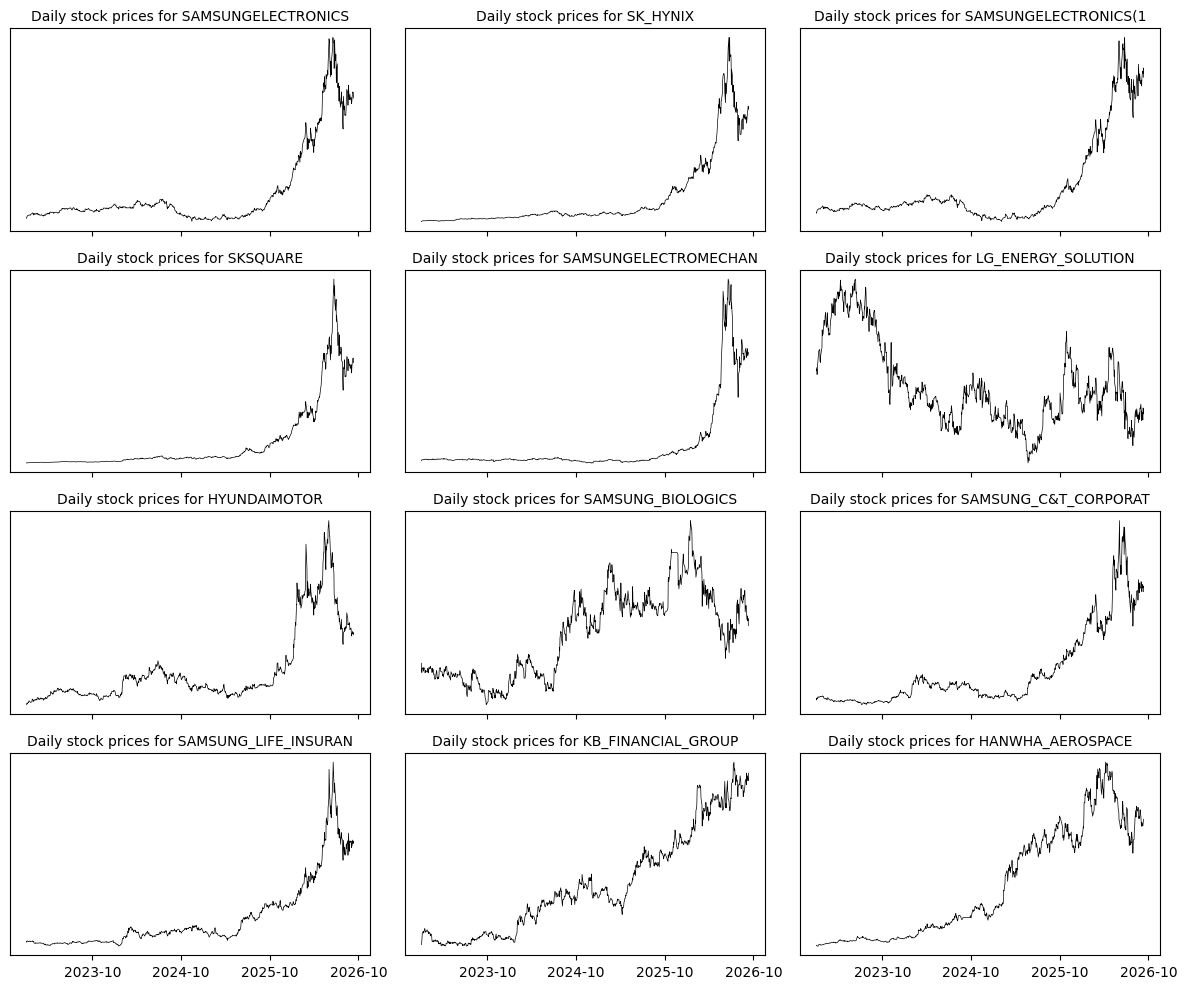

In [34]:
# 차트 갯수와 배치 등
n_plot = len(tickers)
sub_c = 3             #   subplot col 갯수
sub_r = n_plot/sub_c if n_plot%sub_c ==0 else n_plot//sub_c + 1
sub_r = int(sub_r)   # subplot row 갯수, 정수

# 그림판, 서브 플롯 배치, 전체 크기, 축 공유 등
fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5), # (width, height)
                         sharex=True
                         )

# 서브 플롯 반복 생성, (순서, 종목, 별칭) 지정
for ax, ticker, tic_en in zip(axes.flat, tickers, tick_en) :
  ax.plot(
          yymmdd,
          df_dat[f"{ticker}"],
          linewidth=0.5 ,
          color='black' #, 요건 점으로 할 때.
        )
  ax.set_title(f"Daily stock prices for {tic_en}", fontsize=10)
        # ax.set_xlim(-3.5, 3.5)
  ax.set_yticks([])
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

# 결과물 디스플레이
plt.tight_layout()
plt.show()


### plots, daily pct changes

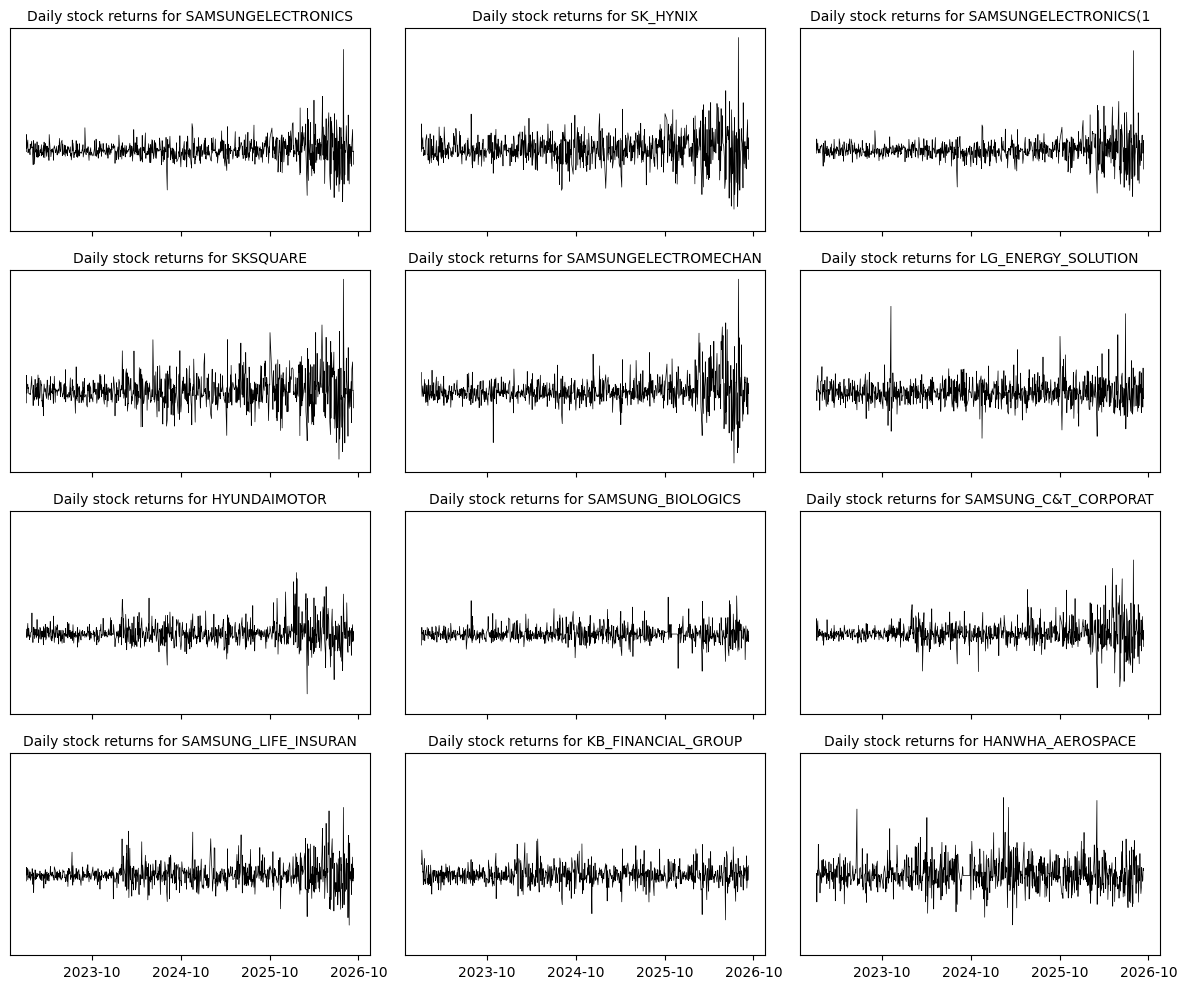

In [35]:
# 일부 중복 코드 생략 가능 (아래 파라메타 값)
n_plot = len(tickers)
sub_c = 3             #   subplot col 갯수
sub_r = n_plot/sub_c if n_plot%sub_c ==0 else n_plot//sub_c + 1
sub_r = int(sub_r)   # subplot row 갯수, 정수

fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5), # (width, height)
                         sharex=True,
                         sharey=True
                         )

for ax, ticker, tic_en in zip(axes.flat, tickers, tick_en) :
  ax.plot(
          yymmdd,
          df_dat[f"{ticker}"].pct_change(),
          linewidth=0.5 ,
          color='black'
        )
  ax.set_title(f"Daily stock returns for {tic_en}", fontsize=10)
  ax.set_yticks([])
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

# 결과 디스플레이
plt.tight_layout()
plt.show()


### histogram, pct changes of daily stock prices

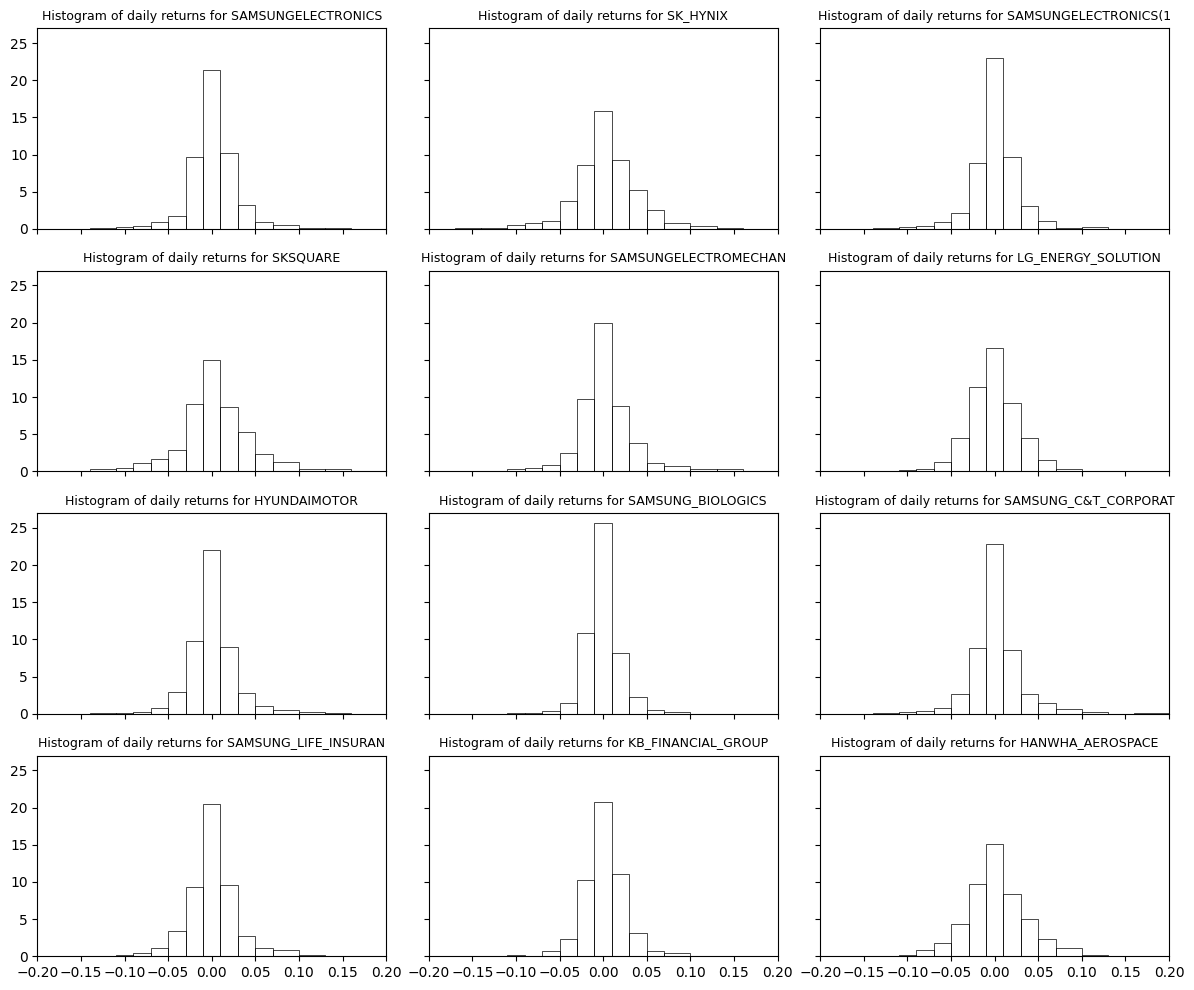

In [36]:
# 일부 중복 코드 생략 가능 (아래 파라메타 값)
n_plot = len(tickers)
sub_c = 3             #   subplot col 갯수
sub_r = n_plot/sub_c if n_plot%sub_c ==0 else n_plot//sub_c + 1
sub_r = int(sub_r)   # subplot row 갯수, 정수

bins = [-0.2, -0.17, -0.14, -0.11, -0.09, -0.07, -0.05, -0.03, -0.01, 0.01, 0.03, 0.05, 0.07, 0.1, 0.13, 0.16,  0.2]
fig, axes = plt.subplots(sub_r, sub_c,
                         figsize=(sub_c*4, sub_r*2.5), # (width, height)
                         sharex=True,
                         sharey=True
                         )

for ax, ticker, tic_en in zip(axes.flat, tickers, tick_en) :
  ax.hist(
      df_dat[f"{ticker}"].pct_change(),
      color='blue',
      linewidth=0.5,
      bins = bins, #16, # 숫자로 갯수 지정, 균등.
      facecolor='None',
      edgecolor='black',
      density=True
      )
  ax.set_title(f"Histogram of daily returns for {tic_en}", fontsize=9)
#  ax.set_title(f"Daily stock return distribution of {tic_en}", fontsize=9)
  ax.set_xlim(-0.2, 0.2)
  #ax.set_ylim( 0, 30)
  #ax.set_yticks([])

# 결과물 디스플레이
plt.tight_layout()
plt.show()
